In [2]:
import json
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [3]:
# weights

ngc1097_weights_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                            'ppxf/weights.fits')

with fits.open(ngc1097_weights_path_miles) as hdul:
    print('\nReading E-MILES weights')
    hdul.info()
    weights_miles = hdul[0].data

# metallicity

ngc1097_metal_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                            'ppxf/mean_mh_light.fits')

with fits.open(ngc1097_metal_path_miles) as hdul:
    print('\nReading E-MILES average metallicity')
    hdul.info()
    metal_miles = hdul[0].data

# age 
ngc1097_age_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                          'ppxf/mean_log10_age_light.fits')

with fits.open(ngc1097_age_path_miles) as hdul:
    print('\nmiles age')
    hdul.info()
    age_miles = hdul[0].data
    
# galaxy
ngc1097_galaxy_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                              'ppxf/galaxy.fits')

with fits.open(ngc1097_galaxy_path_miles, memmap=True) as hdul:
    print('\nGalaxy')
    hdul.info()
    galaxy_miles = hdul[0].data

# bestfit
ngc1097_bestfit_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                             'ppxf/bestfit.fits')

with fits.open(ngc1097_bestfit_path_miles, memmap=True) as hdul:
    print('\nBestfit')
    hdul.info()
    bestfit_miles = hdul[0].data
    
# goodpixels
ngc1097_goodpixels_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                                 'ppxf/goodpixels.fits')

with fits.open(ngc1097_goodpixels_path_miles, memmap=True) as hdul:
    print('\nGoodpixels')
    hdul.info()
    goodpixels_miles = hdul[0].data
        


Reading E-MILES weights
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/weights.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (326, 320, 144)   float32   

Reading E-MILES average metallicity
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/mean_mh_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

miles age
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/mean_log10_age_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

Galaxy
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/galaxy.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (326, 320, 3682)   float32   

Bestfit
Filename: ../../d

In [4]:
# reading metadata

ngc1097_metadata_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/'
                               'metadata.json')

with open(ngc1097_metadata_path_miles) as fp:
    print('\nReading E-MILES metadata')
    meta = json.load(fp)


Reading E-MILES metadata


In [5]:
mh_range = np.array(meta['model']['mh_range'])
# print(mh_range.shape)

age_range = np.array(meta['model']['age_range'])
# print(age_range.shape)

reg_dim = np.array(meta['model']['reg_dim'])
# print(reg_dim)

Average log_10 age:  7.06 Gyr
Average [M/H]:  0.04 dex


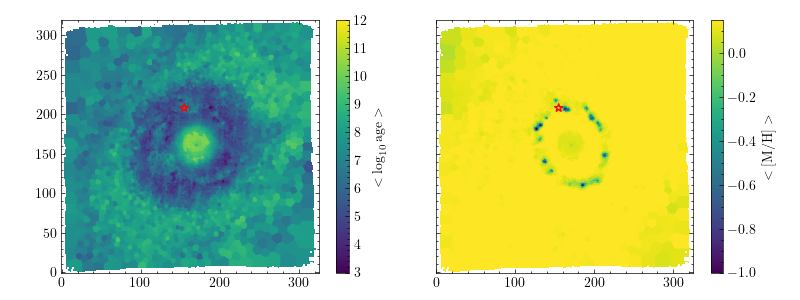

In [6]:
%matplotlib widget

with plt.style.context('science'):
    fig, ax = plt.subplots(1, 2, tight_layout=True, sharex=True, sharey=True, figsize=(8, 3))

    # position = (208, 163) # (y, x)
    position = (208, 155) # (y, x)
    # position = (160, 213) # (y, x)
    # position = (248, 194) # (y, x)

    im0 = ax[0].imshow(10**(age_miles-9), origin='lower', vmin=3, vmax=12)
    ax[0].scatter(*reversed(position), marker ='*', facecolors='none', edgecolors='r')
    cbar0 = plt.colorbar(im0, ax=ax[0])
    cbar0.set_label(r'$<\log_{10} \rm{age}>$')

    im1 = ax[1].imshow(metal_miles, origin='lower', vmin=-1., vmax=0.15)
    ax[1].scatter(*reversed(position), marker ='*', facecolors='none', edgecolors='r')
    cbar1 = plt.colorbar(im1, ax=ax[1])
    cbar1.set_label(r'$<\rm{[M/H]}>$')
    
print(rf'Average log_10 age: {10**(age_miles[position]-9): .2f} Gyr')
print(f'Average [M/H]: {metal_miles[position]: .2f} dex')


In [7]:
print(fig.get_figheight())
print(fig.get_figwidth())

3.0
8.0


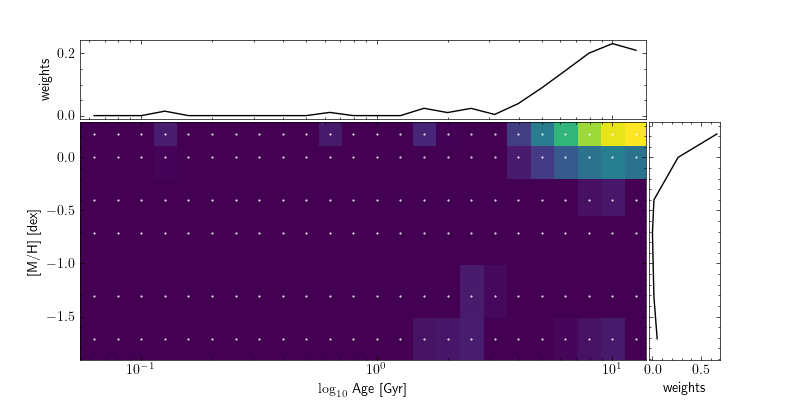

In [8]:
with plt.style.context('science'):
    fig = plt.figure(figsize=(8, 4))

    gs = fig.add_gridspec(2, 2,  width_ratios=(8, 1), height_ratios=(1, 3),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.01, hspace=0.02)

    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    # ax_bar = fig.add_subplot(gs[0, 1])

    w = weights_miles[slice(None), position[0], position[1]].reshape(reg_dim)
    w = w/w.sum()
    mh_grid, age_grid = np.meshgrid(mh_range, age_range)

    im0 = ax.pcolormesh(age_grid.T, mh_grid.T, w.T)
    points = ax.scatter(age_grid, mh_grid,
                        marker ='.', color ='white', s = 1)
    # cbar = plt.colorbar(im0, ax=ax_bar, fraction=1)
    # ax_bar.axis('off')
    # cbar.set_label('weights')
    
    ax.set_xscale('log')
    ax.set_yscale('linear')

    ax_histx.plot(age_range, np.nansum(w, 1), color='black')
    ax_histy.plot(np.nansum(w, 0), mh_range, color='black')

    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    ax.set_xlabel('$\log_{10}$ Age [Gyr]')
    ax.set_ylabel('[M/H] [dex]')

    ax_histx.set_ylabel('weights')
    ax_histy.set_xlabel('weights')

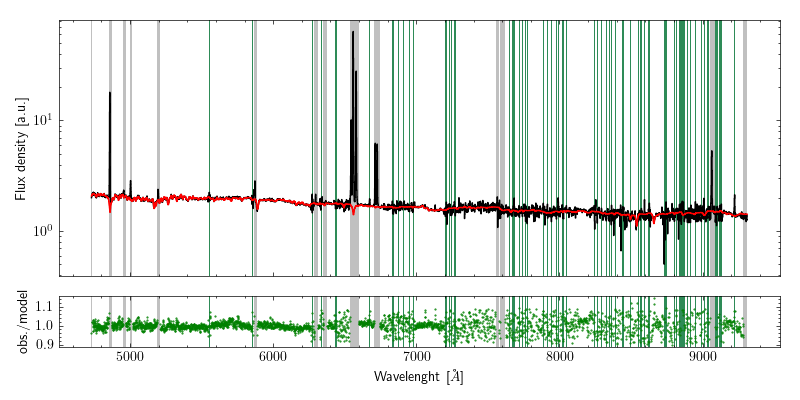

In [9]:
import spectcube as sc

def check_inside(wave, fixed_mask:list):
    for bound in fixed_mask:
        if (wave > bound[0]) & (wave < bound[1]):
            return True
    return False

with plt.style.context('science'):
    fig, ax = plt.subplots(2, 1, tight_layout=True, figsize=(8,4), height_ratios=[5, 1], sharex=True)
    bestfit = bestfit_miles[slice(None), position[0], position[1]]
    galaxy = galaxy_miles[slice(None), position[0], position[1]]
    goodpixels = goodpixels_miles[slice(None), position[0], position[1]]
    goodpixels = goodpixels[np.isfinite(goodpixels)]
    goodpixels = np.asarray(goodpixels, dtype=int)
    mask = np.full_like(galaxy, fill_value=True, dtype=bool)
    mask[goodpixels] = False
    wave = np.asarray(meta['obs']['wave_obs'])
    bound = sc.util._build_edges(wave, 'ln')
    fixed_mask = meta['conf']['observation']['fixed_spectral_mask']
    
    # ax[0].plot(wave, galaxy, label='Reddening corrected obs.', color='k')
    # ax[0].plot(wave, bestfit, label='Bestfit', color='red')
    ax[0].step(wave, galaxy, label='Reddening corrected obs.', color='k')
    ax[0].step(wave, bestfit, label='Bestfit', color='red')
    ax[0].set_yscale('log')
    
    ax[1].plot(wave, np.ma.masked_where(mask, galaxy/bestfit), '.', color='green', ms=1)

    ax[0].set_ylabel('Flux density [a.u.]')
    ax[1].set_ylabel(r'obs./model')
    ax[1].set_xlabel(r'Wavelenght [$\AA$]')
    
    # shade regions
    for j in range(wave.size):
        if check_inside(wave[j], fixed_mask):
            lw = bound[j]
            up = bound[j+1]
            ax[0].axvspan(lw, up, color='silver', alpha=1, lw=0)
            ax[1].axvspan(lw, up, color='silver', alpha=1, lw=0)
        elif j not in goodpixels:
            lw = bound[j]
            up = bound[j+1]
            ax[0].axvspan(lw, up, color='seagreen', alpha=1, lw=0)
            ax[1].axvspan(lw, up, color='seagreen', alpha=1, lw=0)
            



/tmp/ipykernel_12390/3698552678.py:10: RuntimeWarning: invalid value encountered in divide
  mean_age = a/b
/tmp/ipykernel_12390/3698552678.py:18: RuntimeWarning: invalid value encountered in divide
  mean_log10_age = a/b


<Age> [Gy]:  8.21
10**<log10 Age> [Gyr]:  7.06


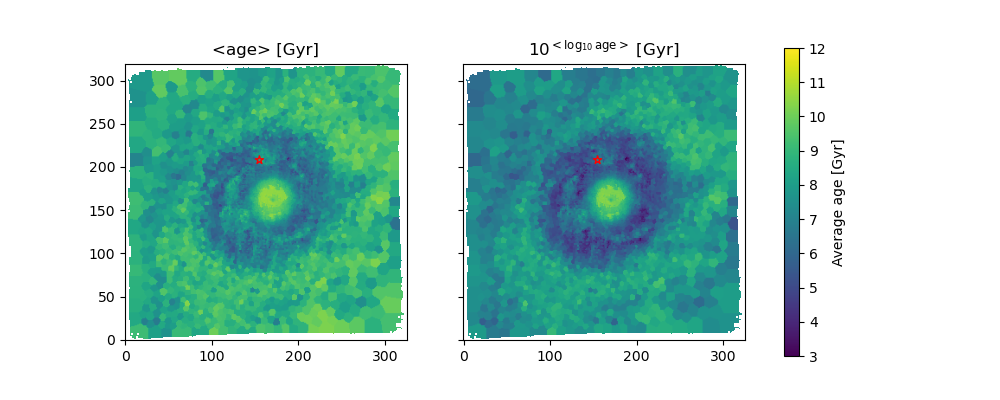

In [10]:
# print(weights_miles.shape)
# print(age_grid.ravel()[None, None, :].shape)
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 4))

vmin = 3
vmax = 12

a = np.nansum(weights_miles * age_grid.ravel()[:, None, None], 0)
b = np.nansum(weights_miles, 0)
mean_age = a/b

im0 = ax[0].imshow(mean_age, origin='lower', vmin=vmin, vmax=vmax)
ax[0].scatter(*reversed(position), marker ='*', facecolors='none', edgecolors='r')
ax[0].set_title(r'<age> [Gyr]')

a = np.nansum(weights_miles * np.log10(age_grid.ravel()*1e9)[:, None, None], 0)
b = np.nansum(weights_miles, 0)
mean_log10_age = a/b
# ax[1].imshow(mean_log10_age, origin='lower', vmin=None, vmax=None)
# ax[1].scatter(*reversed(position), marker ='*', facecolors='none', edgecolors='r')
# ax[1].set_title(r'<$\log_{10}$ age> [yr]')

ax[1].imshow(10**(mean_log10_age-9), origin='lower', vmin=vmin, vmax=vmax)
ax[1].scatter(*reversed(position), marker ='*', facecolors='none', edgecolors='r')
ax[1].set_title(r'$10^{<\log_{10} \rm{age}>}$ [Gyr]')

cbar0 = plt.colorbar(im0, ax=ax[:])
cbar0.set_label(r'Average age [Gyr]')

print(f'<Age> [Gy]: {mean_age[position]: .2f}')
print(f'10**<log10 Age> [Gyr]: {10**(mean_log10_age[position] - 9): .2f}')


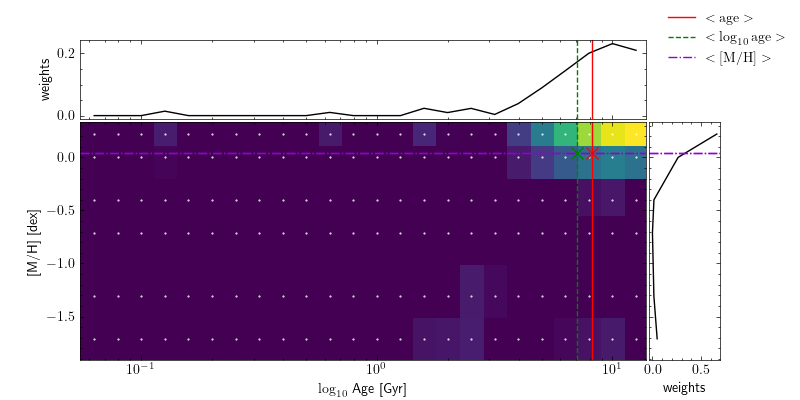

In [10]:
with plt.style.context('science'):
    fig = plt.figure(figsize=(8, 4))

    gs = fig.add_gridspec(2, 2,  width_ratios=(8, 1), height_ratios=(1, 3),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.01, hspace=0.02)

    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    w = weights_miles[slice(None), position[0], position[1]].reshape(reg_dim)
    w = w/w.sum()
    mh_grid, age_grid = np.meshgrid(mh_range, age_range)

    ax.pcolormesh(age_grid.T, mh_grid.T, w.T)
    points = ax.scatter(age_grid, mh_grid,
                        marker ='.', color ='white', s = 1)
    ax.set_xscale('log')
    ax.set_yscale('linear')

    ax_histx.plot(age_range, np.nansum(w, 1), color='k')
    ax_histy.plot(np.nansum(w, 0), mh_range, color='k')

    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    ax.set_xlabel('$\log_{10}$ Age [Gyr]')
    ax.set_ylabel('[M/H] [dex]')

    ax_histx.set_ylabel('weights')
    ax_histy.set_xlabel('weights')

    ax_histx.axvline(mean_age[position], ls='-', lw=1, color='r',label=r'$<\rm{age}>$')
    ax_histy.axhline(metal_miles[position], ls='-.', lw=1, color='darkviolet')
    ax.axvline(mean_age[position], ls='-', lw=1, color='r')
    ax.axhline(metal_miles[position], ls='-.', lw=1, color='darkviolet')
    ax.plot(mean_age[position], metal_miles[position], 'x', color='r', ms=8)
    # print(f'{mean_age[position]}')
        
    ax_histx.axvline(10**(mean_log10_age[position]-9), lw=1, ls='dashed', color='green', label=r'$<\log_{10} \rm{age}>$')
    ax_histy.axhline(metal_miles[position], ls='-.', lw=1, color='darkviolet', label=r'$<\rm{[M/H]}>$')
    ax.axvline(10**(mean_log10_age[position]-9), ls='dashed', lw=1, color='green')
    ax.axhline(metal_miles[position], ls='-.', lw=1, color='darkviolet')
    ax.plot(10**(mean_log10_age[position]-9), metal_miles[position], 'x', color='green', ms=8)
    # print(f'{10**(mean_log10_age[position]-9)}')
    
    fig.legend()

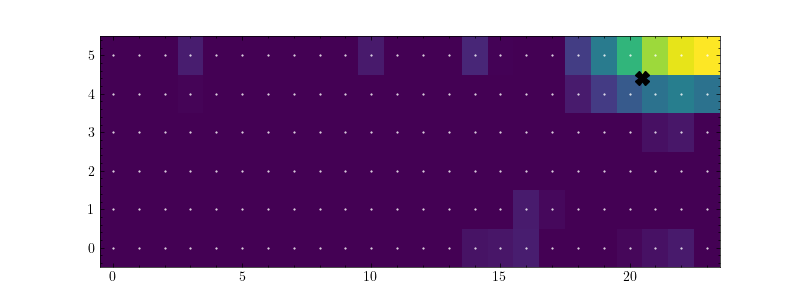

In [27]:
with plt.style.context('science'):
    fig, ax = plt.subplots(1,1, figsize=(8, 3))

    w = weights_miles[slice(None), position[0], position[1]].reshape(reg_dim)
    w = w/w.sum()
    y_grid, x_grid = np.meshgrid(np.arange(mh_range.size), np.arange(age_range.size))

    ax.pcolormesh(x_grid.T, y_grid.T, w.T)
    points = ax.scatter(x_grid, y_grid,
                        marker ='.', color ='white', s = 1)
    
    mean_y =  np.sum(y_grid * w)/ w.sum()
    mean_x = np.sum(x_grid * w)/ w.sum()

    # ax[0].set_xscale('log')
    ax.plot(mean_x, mean_y, 'X', color='black', ms=10)
